In [20]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import pandas as pd
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames
import re
big_plt_font()

In [21]:
data_dir = '/home/electron/data/experiment_07062026'
all_files = list_filenames(data_dir)

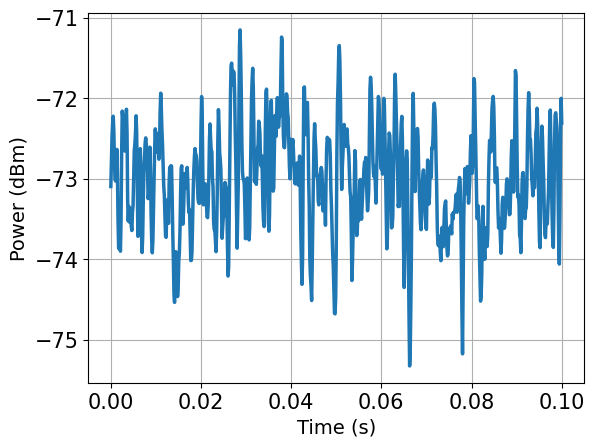

In [224]:
file = load_latest_data() 
data = file['all_meas'] 
t_seq_end = file['t_data']
t_axis = np.linspace(0, t_seq_end, len(data_avg)) 
data_avg = np.mean(data, axis=0) 
plot(t_axis, data_avg, xlabel='Time (s)', ylabel='Power (dBm)')

In [14]:
file['filename']

'/home/electron/data/experiment_07062026/RFPowerSweepOnOff_18-11-16.h5'

interactive(children=(IntSlider(value=2, description='i', max=4), Output()), _dom_classes=('widget-interact',)…

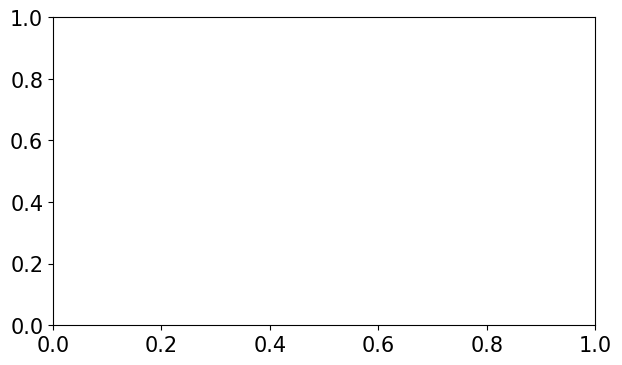

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact

# Dummy data setup
# np.random.seed(42)
# data = [{'x': np.linspace(0, 10, 100), 'y': np.sin(np.linspace(0, 10, 100) * (i + 1) * 0.5) * (10 - i)} for i in range(10)]

# The plotting function completely handles the redraw
def update_plot(i):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(t_axis*1e3, data[i], color='blue', lw=2)
    ax.set_title(f"Plotting dataset i = {i}")
    ax.set_xlabel("Wait time (ms)")
    ax.set_ylabel("Power (dBm)")
    ax.grid(True)
    plt.show() # Explicitly force the redraw

# Create the interactive slider natively
interact(update_plot, i=(0, len(data) - 1, 1));

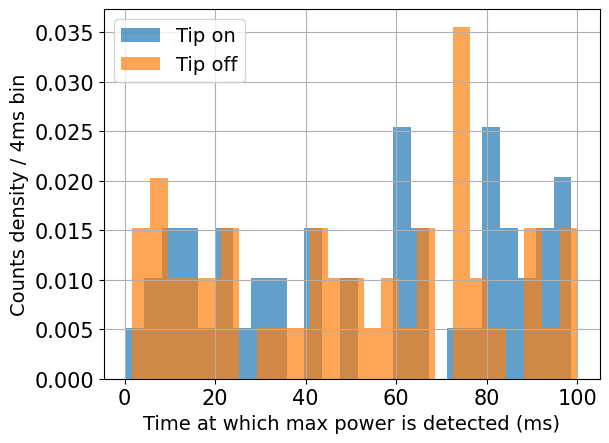

In [212]:
peak_time = []
for i in range(len(data)): 
    peak_time.append(t_axis[np.argmax(data[i])]*1e3) 
plt.hist(peak_time, bins=25, lw=2, label='Tip on', alpha=0.7, density=True)
peak_time = []
for i in range(len(data2)): 
    peak_time.append(t_axis2[np.argmax(data2[i])]*1e3) 
plt.hist(peak_time, bins=25, lw=2, label='Tip off', alpha=0.7, density=True)
plt.xlabel('Time at which max power is detected (ms)') 
plt.ylabel('Counts density / 4ms bin') 
plt.legend()
plt.grid() 
plt.show()

In [71]:
file2['filename']

'/home/electron/data/experiment_07062026/RFPowerSweepOnOff_19-06-42.h5'

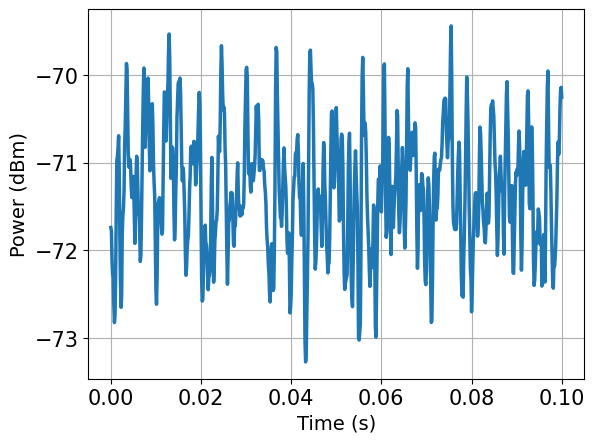

In [8]:
file2 = load_h5_data('RFPowerSweepOnOff_19-06-42_data.h5', base=data_dir) 
data2 = file2['all_meas'] 
t_seq_end2 = file2['t_data']
t_axis2 = np.linspace(0, t_seq_end2, len(data2[0])) 
data_avg2 = np.mean(data2, axis=0) 
plot(t_axis2, data_avg2, xlabel='Time (s)', ylabel='Power (dBm)')

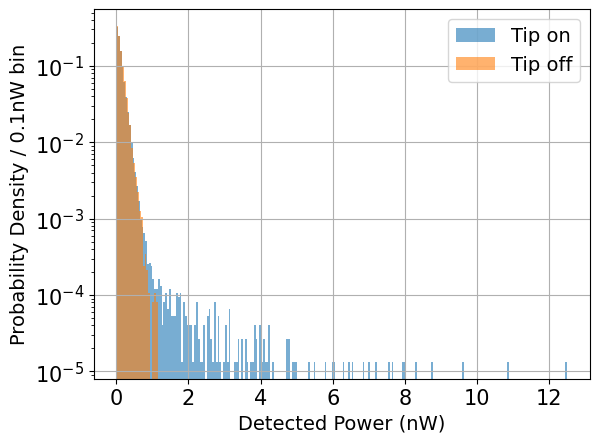

In [11]:
file = load_h5_data('/home/electron/data/experiment_07062026/RFPowerSweepOnOff_18-11-16_data.h5') #load_latest_data() #
data = file['all_meas'] 
P_nW = dBm_to_W(np.concatenate(data, axis=0))*1e9 
P_nW_background = dBm_to_W(np.concatenate(data2, axis=0))*1e9
bin_size = 0.05

counts, bin_edges = np.histogram(P_nW, bins=int((max(P_nW)-min(P_nW))/bin_size))#, alpha=0.7, label='Tip on')
plt.bar(
    bin_edges[:-1],          # X-coordinates: Use all edges except the very last one
    counts/np.sum(counts),                  # Y-coordinates: The heights of the bars
    width=np.diff(bin_edges),# Width of each bar (difference between adjacent edges)
    label='Tip on',
    align='edge',            # Align the bars to start at the left bin edge
    alpha=0.6                # Transparency
)

counts, bin_edges = np.histogram(P_nW_background, bins=int((max(P_nW_background)-min(P_nW_background))/bin_size))#, alpha=0.7, label='Tip off')
# plt.xscale('log') 
plt.bar(
    bin_edges[:-1],          # X-coordinates: Use all edges except the very last one
    counts/np.sum(counts),                  # Y-coordinates: The heights of the bars
    width=np.diff(bin_edges),# Width of each bar (difference between adjacent edges)
    label='Tip off',
    align='edge',            # Align the bars to start at the left bin edge
    alpha=0.6                # Transparency
)



plt.yscale('log')
plt.xlabel('Detected Power (nW)') 
plt.ylabel('Probability Density / 0.1nW bin')
plt.grid()
plt.legend()
plt.show()

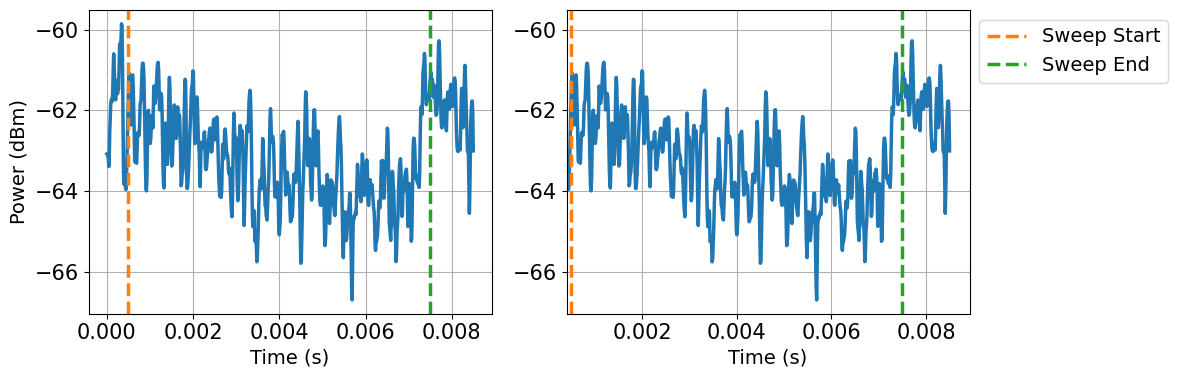

In [51]:
file = load_latest_data() 
data = file['all_meas'] 

t_start = file['t_sweep_start'] - file['t_tip_settle']
t_sweep_start = file['t_tip_settle']
t_sweep_end = t_sweep_start+file['ramp_time']#file['t_sweep_end'] - t_start - file['hold_time']
t_tip_off = [file['SSA_SWT']] #file['t_tip_off'] - t_start - file['hold_time']
t_seq_end = file['SSA_SWT']
data_avg = np.mean(data, axis=0) 
fig, ax = plt.subplots(ncols=2, figsize=(12,4))
t_axis = np.linspace(0, t_seq_end, len(data_avg)) 
T_zoom_expansion = 1e-4
plot_ax(ax[0], t_axis, data_avg, xlabel='Time (s)', ylabel='Power (dBm)')
plot_ax(ax[1], t_axis, data_avg, xlabel='Time (s)')
ax[0].axvline(t_sweep_start, linestyle='--', c='C1', label='Sweep Start')
ax[0].axvline(t_sweep_end, linestyle='--', c='C2', label='Sweep End') 
# ax[0].axvline(t_tip_off[-1], linestyle='--', c='C3', label='Tip Off') 
ax[1].axvline(t_sweep_start, linestyle='--', c='C1', label='Sweep Start')
ax[1].axvline(t_sweep_end, linestyle='--', c='C2', label='Sweep End') 
# ax[1].axvline(t_tip_off[-1], linestyle='--', c='C3', label='Tip Off') 
ax[1].set_xlim((t_sweep_start-T_zoom_expansion, None))
ax[1].legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

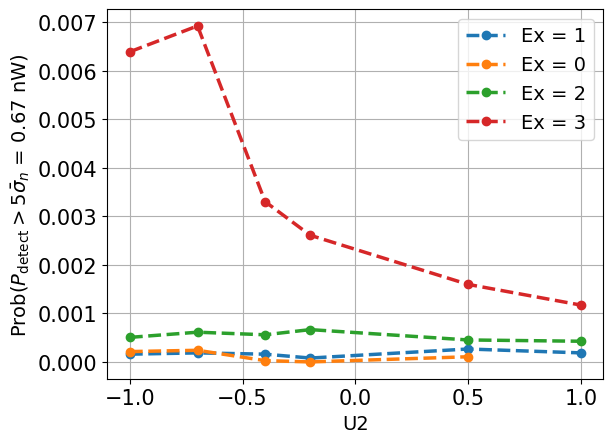

In [237]:
all_files = list_filenames(data_dir)
all_meas = {}
P_th = np.mean(P_nW_background)+5*np.std(P_nW_background) # nW
for file in all_files: 
    if "RFPowerSweepOnOff" in file and "old" not in file and "data" not in file: 
        file = load_h5_data(file, base=data_dir) 
        data = np.concatenate(dBm_to_W(file['all_meas'])*1e9, axis=0)
        t_seq_end = file['t_data']
        if file['Ex'] in all_meas:
            all_meas[file['Ex']].append( [file['U2'], len(data[np.where(data > P_th)])/len(data)] )
        else:
            all_meas[file['Ex']] = [[file['U2'], len(data[np.where(data > P_th)])/len(data)]]

for Ex in all_meas: 
    U2, data = np.array(all_meas[Ex]).T
    sort_idx = np.argsort(U2) 
    plot(np.array(U2)[sort_idx], np.array(data)[sort_idx], '.--', label=f'Ex = {Ex}', xlabel='U2', ylabel=r'Prob($P_{\text{detect}} > 5\bar{\sigma}_n$'+f' = {P_th:.2f} nW)')
# plt.yscale('log')

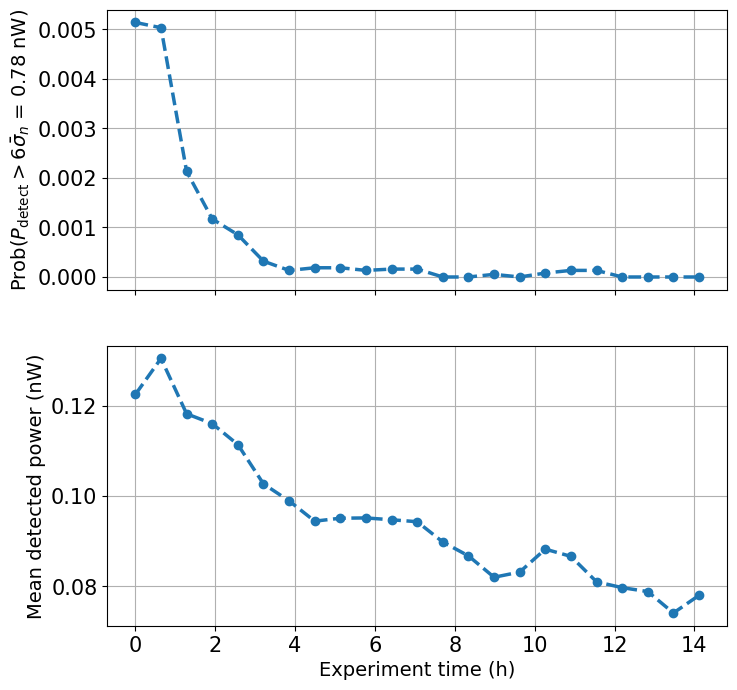

In [18]:
all_files = list_filenames(data_dir)
all_meas = {}
P_th = np.mean(P_nW_background)+6*np.std(P_nW_background) # nW
for file in all_files: 
    if "RFPowerSweepOnOff" in file and "old" not in file and "data" not in file: 
        file = load_h5_data(file, base=data_dir) 
        data = np.concatenate(dBm_to_W(file['all_meas'])*1e9, axis=0)
        t_seq_end = file['t_data']
        if file['Ex'] in all_meas:
            all_meas[file['Ex']].append( [file['U2'], len(data[np.where(data > P_th)])/len(data), np.mean(data)] )
        else:
            all_meas[file['Ex']] = [[file['U2'], len(data[np.where(data > P_th)])/len(data), np.mean(data)]]
all_data = []
all_mean = []
for Ex in np.sort(list(all_meas.keys()))[::-1]: 
    U2, data, mean = np.array(all_meas[Ex]).T
    sort_idx = np.argsort(U2) 
    all_data.extend(np.array(data)[sort_idx])
    all_mean.extend(np.array(mean)[sort_idx])
fig, ax = plt.subplots(nrows=2, figsize=(8,8), sharex=True)
plot_ax(ax[0], np.arange(len(all_data))*38.5/60, all_data, '.--', ylabel=r'Prob($P_{\text{detect}} > 6\bar{\sigma}_n$'+f' = {P_th:.2f} nW)')
plot_ax(ax[1], np.arange(len(all_data))*38.5/60, all_mean, '.--', xlabel='Experiment time (h)', ylabel=r'Mean detected power (nW)')
# plt.yscale('log')

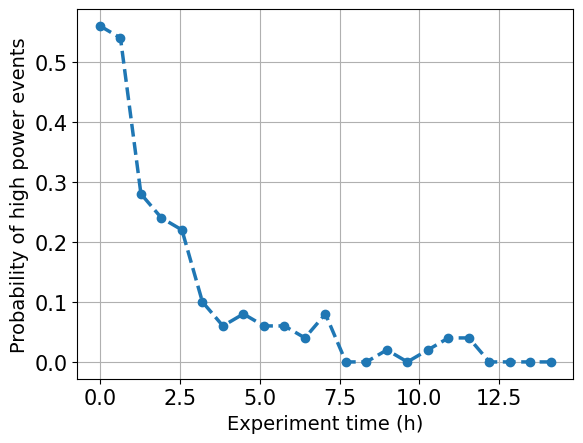

In [261]:
all_files = list_filenames(data_dir)
all_meas = {}
P_th = np.mean(P_nW_background)+6*np.std(P_nW_background) # nW
for file in all_files: 
    if "RFPowerSweepOnOff" in file and "old" not in file and "data" not in file: 
        file = load_h5_data(file, base=data_dir) 
        data = sum([1 for i in dBm_to_W(file['all_meas'])*1e9 if np.any(i > P_th)])/len(file['all_meas'])
        t_seq_end = file['t_data']
        if file['Ex'] in all_meas:
            all_meas[file['Ex']].append( [file['U2'], data] )
        else:
            all_meas[file['Ex']] = [[file['U2'], data]]
all_data = []
for Ex in np.sort(list(all_meas.keys()))[::-1]: 
    U2, data = np.array(all_meas[Ex]).T
    sort_idx = np.argsort(U2) 
    all_data.extend(np.array(data)[sort_idx])
plot(np.arange(len(all_data))*38.5/60, all_data, '.--', xlabel='Experiment time (h)', ylabel=r'Probability of high power events')
# plt.yscale('log')

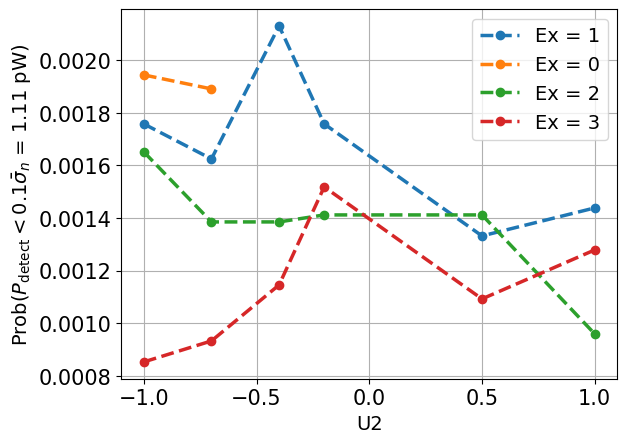

In [236]:
all_files = list_filenames(data_dir)
all_meas = {}
P_th = 0.01*np.std(P_nW_background) # nW
for file in all_files: 
    if "RFPowerSweepOnOff" in file and "old" not in file and "data" not in file: 
        file = load_h5_data(file, base=data_dir) 
        data = np.concatenate(dBm_to_W(file['all_meas'])*1e9, axis=0)
        t_seq_end = file['t_data']
        if file['Ex'] in all_meas:
            all_meas[file['Ex']].append( [file['U2'], len(data[np.where(data < P_th)])/len(data)] )
        else:
            all_meas[file['Ex']] = [[file['U2'], len(data[np.where(data < P_th)])/len(data)]]

for Ex in all_meas: 
    U2, data = np.array(all_meas[Ex]).T
    sort_idx = np.argsort(U2) 
    plot(np.array(U2)[sort_idx], np.array(data)[sort_idx], '.--', label=f'Ex = {Ex}', xlabel='U2', ylabel=r'Prob($P_{\text{detect}} < 0.1\bar{\sigma}_n$'+f' = {P_th*1e3:.2f} pW)')
# plt.yscale('log')